# 1.Import Libararies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load Dataset

In [4]:
fraud_data = pd.read_csv("PS_20174392719_1491204439457_log.csv")

fraud_data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# 3. Data Understanding

In [6]:
fraud_data.shape

(6362620, 11)

In [10]:
fraud_data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [11]:
fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [12]:
fraud_data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [13]:
fraud_data.duplicated().sum()

np.int64(0)

In [14]:
fraud_data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [15]:
fraud_data["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [16]:
fraud_data["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

# 4. Data Cleaning

In [18]:
fraud_data.drop_duplicates(inplace=True)

In [20]:
fraud_data.shape

(6362620, 11)

In [21]:
fraud_data[["amount", "oldbalanceOrg", "newbalanceOrig","oldbalanceDest", "newbalanceDest"]].min()

amount            0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
oldbalanceDest    0.0
newbalanceDest    0.0
dtype: float64

In [22]:
fraud_data[["isFraud", "isFlaggedFraud"]].apply(
    lambda x: x.value_counts()
)

,isFraud,isFlaggedFraud
0,6354407,6362604
1,8213,16


# 5. Exploratory Data Analysis

## 1. Fraud percentage:

In [26]:
# Calculate the percentage of normal and fraudulent transactions
fraud_percentage = fraud_data["isFraud"].value_counts(normalize=True) * 100

fraud_percentage

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

## 2. Transaction type-wise fraud count:

In [27]:
# Find the number of fraudulent transactions in each transaction type
fraud_by_type = fraud_data.groupby("type")["isFraud"].sum().sort_values(ascending=False)

fraud_by_type

type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64

## 3. Normal vs Fraud — average transaction amount:

In [28]:
# Compare the average transaction amount between normal and fraudulent transactions
average_amount = fraud_data.groupby("isFraud")["amount"].mean()

average_amount

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

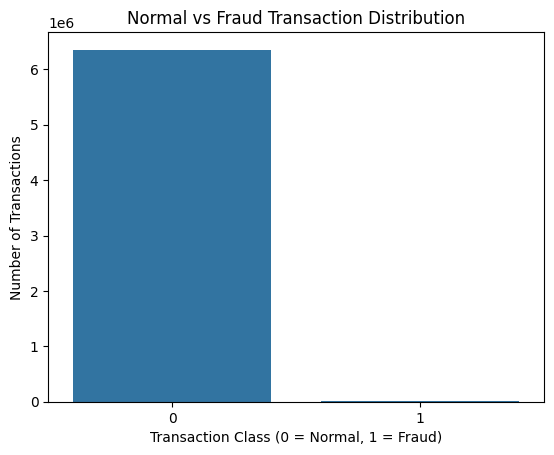

In [29]:
# Visualize the distribution of normal and fraudulent transactions
sns.countplot(x="isFraud", data=fraud_data)

plt.title("Normal vs Fraud Transaction Distribution")
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

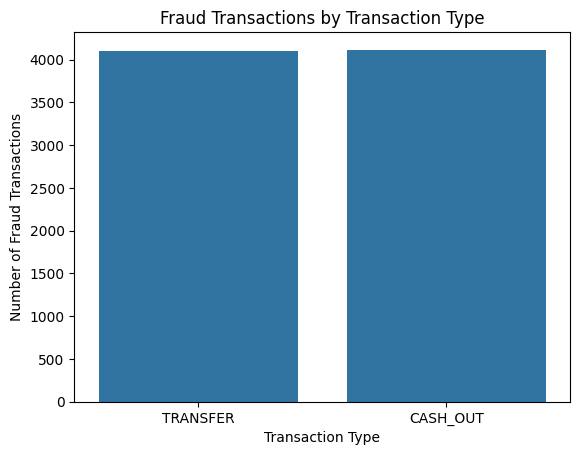

In [30]:
# Filter only fraudulent transactions
fraud_transactions = fraud_data[fraud_data["isFraud"] == 1]

# Visualize fraud transactions by transaction type
sns.countplot(x="type", data=fraud_transactions)

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")
plt.show()

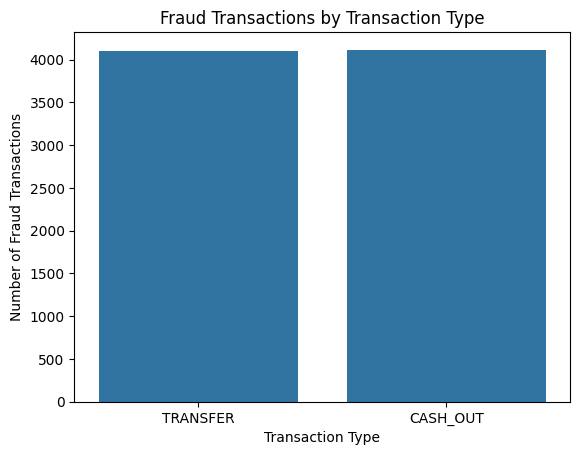

In [31]:
# Filter only fraudulent transactions
fraud_transactions = fraud_data[fraud_data["isFraud"] == 1]

# Visualize fraud transactions by transaction type
sns.countplot(x="type", data=fraud_transactions)

plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")
plt.show()

In [32]:
# Compare the average sender account balances for normal and fraudulent transactions
sender_balance_analysis = fraud_data.groupby("isFraud")[
    ["oldbalanceOrg", "newbalanceOrig"]
].mean()

sender_balance_analysis

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,8.328287e+05,855970.228109
1,1.649668e+06,192392.631836


In [33]:
# Compare actual fraud cases with transactions already flagged as fraud
fraud_flag_analysis = pd.crosstab(
    fraud_data["isFraud"],
    fraud_data["isFlaggedFraud"]
)

fraud_flag_analysis

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


In [34]:
# Select numerical columns for correlation analysis
numerical_data = fraud_data[
    ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
     "oldbalanceDest", "newbalanceDest", "isFraud"]
]

# Calculate correlation between numerical variables
correlation_matrix = numerical_data.corr()

correlation_matrix

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


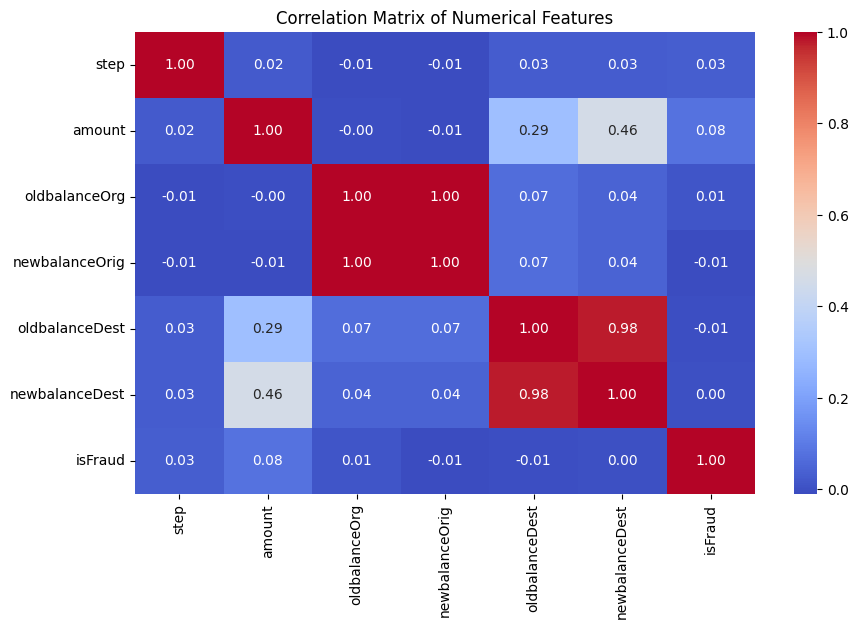

In [36]:
# Visualize correlations between numerical variables
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [37]:
# Calculate the fraud percentage for each transaction type
fraud_rate_by_type = (
    fraud_data.groupby("type")["isFraud"].mean() * 100
).sort_values(ascending=False)

fraud_rate_by_type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [38]:
# Display descriptive statistics only for fraudulent transactions
fraud_transactions[
    ["amount", "oldbalanceOrg", "newbalanceOrig",
     "oldbalanceDest", "newbalanceDest"]
].describe()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,8.213000e+03,8.213000e+03,8.213000e+03,8.213000e+03,8.213000e+03
mean,1.467967e+06,1.649668e+06,1.923926e+05,5.442496e+05,1.279708e+06
std,2.404253e+06,3.547719e+06,1.965666e+06,3.336421e+06,3.908817e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.270913e+05,1.258224e+05,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.414234e+05,4.389835e+05,0.000000e+00,0.000000e+00,4.676420e+03
75%,1.517771e+06,1.517771e+06,0.000000e+00,1.478287e+05,1.058725e+06
max,1.000000e+07,5.958504e+07,4.958504e+07,2.362305e+08,2.367265e+08


# 6. Data Preprocessing

In [39]:
# Remove customer account identifiers because they are not useful for model training
model_data = fraud_data.drop(["nameOrig", "nameDest"], axis=1)

model_data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [44]:
# Check the columns available in model_data
model_data.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

In [48]:
# Separate the input features and target variable
X = model_data.drop(["isFraud", "isFlaggedFraud"], axis=1)
X.shape

(6362620, 10)

In [49]:
y = model_data["isFraud"]
y.shape

(6362620,)

In [50]:
# Import train_test_split for separating training and testing data
from sklearn.model_selection import train_test_split

# Split the dataset while maintaining the same fraud proportion in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5090096, 10), (1272524, 10))

In [51]:
# Check the fraud distribution in the training data
y_train.value_counts()

isFraud
0    5083526
1       6570
Name: count, dtype: int64

In [52]:
# Check the fraud distribution in the testing data
y_test.value_counts()

isFraud
0    1270881
1       1643
Name: count, dtype: int64

# 7. Machine Learning Models


## 7.1 Logistic Regression

In [53]:
# Import StandardScaler to scale numerical features
from sklearn.preprocessing import StandardScaler

# Create copies so the original train and test data remain unchanged
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Select numerical columns that require scaling
scale_columns = [
    "step", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest"
]

# Scale the numerical features using only the training data
scaler = StandardScaler()

X_train_scaled[scale_columns] = scaler.fit_transform(
    X_train[scale_columns]
)

X_test_scaled[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

In [57]:
# Import and train the Logistic Regression model
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42)

In [58]:
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
# Predict normal and fraudulent transactions using the test data
logistic_pred = logistic_model.predict(X_test_scaled)

logistic_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

## 7.2 Logistic Regression Model Evaluation

In [62]:
# Import classification model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate Logistic Regression performance
log_accuracy = accuracy_score(y_test, logistic_pred)
log_precision = precision_score(y_test, logistic_pred)
log_recall = recall_score(y_test, logistic_pred)
log_f1 = f1_score(y_test, logistic_pred)

print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Accuracy : 0.948959705278643
Precision: 0.023728201501632535
Recall   : 0.9598295800365185
F1 Score : 0.04631152355221426


In [63]:
# Display detailed classification performance for normal and fraud classes
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    logistic_pred,
    target_names=["Normal", "Fraud"]
))

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97   1270881
       Fraud       0.02      0.96      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [64]:
# Create a confusion matrix to understand correct and incorrect predictions
from sklearn.metrics import confusion_matrix

log_confusion_matrix = confusion_matrix(y_test, logistic_pred)

log_confusion_matrix

array([[1205997,   64884],
       [     66,    1577]])

## 7.3 Decision Tree Classifier

In [65]:
# Import and train the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [66]:
# Predict normal and fraudulent transactions using the test data
decision_tree_pred = decision_tree_model.predict(X_test)

decision_tree_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [67]:
# Evaluate the Decision Tree model
dt_accuracy = accuracy_score(y_test, decision_tree_pred)
dt_precision = precision_score(y_test, decision_tree_pred)
dt_recall = recall_score(y_test, decision_tree_pred)
dt_f1 = f1_score(y_test, decision_tree_pred)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.9996950941593243
Precision: 0.8885448916408669
Recall   : 0.8734023128423616
F1 Score : 0.8809085328422345


In [68]:
# Display detailed classification report for Decision Tree
print(classification_report(
    y_test,
    decision_tree_pred,
    target_names=["Normal", "Fraud"]
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1270881
       Fraud       0.89      0.87      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.94      0.94      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524



In [69]:
# Create confusion matrix for Decision Tree predictions
dt_confusion_matrix = confusion_matrix(
    y_test,
    decision_tree_pred
)

dt_confusion_matrix# Create confusion matrix for Decision Tree predictions
dt_confusion_matrix = confusion_matrix(
    y_test,
    decision_tree_pred
)

dt_confusion_matrix

array([[1270701,     180],
       [    208,    1435]])

In [71]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [73]:
# Train the Random Forest model using the training data
random_forest_model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
# Predict normal and fraudulent transactions using the test data
random_forest_pred = random_forest_model.predict(X_test)

random_forest_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [75]:
# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, random_forest_pred)
rf_precision = precision_score(y_test, random_forest_pred)
rf_recall = recall_score(y_test, random_forest_pred)
rf_f1 = f1_score(y_test, random_forest_pred)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.9997021667174844
Precision: 0.9809741248097412
Recall   : 0.7845404747413268
F1 Score : 0.8718295569834291


# 8. Model Comparison

In [76]:
# Compare the performance of all three classification models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        log_f1,
        dt_f1,
        rf_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.948960,0.023728,0.959830,0.046312
1,Decision Tree,0.999695,0.888545,0.873402,0.880909
2,Random Forest,0.999702,0.980974,0.784540,0.871830


In [77]:
# Identify the model with the highest F1 Score
best_model_result = model_comparison.loc[
    model_comparison["F1 Score"].idxmax()
]

best_model_result

Model        Decision Tree
Accuracy          0.999695
Precision         0.888545
Recall            0.873402
F1 Score          0.880909
Name: 1, dtype: object

In [78]:
# Select the best model based on the highest F1 Score
best_model_name = best_model_result["Model"]

if best_model_name == "Logistic Regression":
    final_predictions = logistic_pred
    fraud_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

elif best_model_name == "Decision Tree":
    final_predictions = decision_tree_pred
    fraud_probability = decision_tree_model.predict_proba(X_test)[:, 1]

else:
    final_predictions = random_forest_pred
    fraud_probability = random_forest_model.predict_proba(X_test)[:, 1]

best_model_name

'Decision Tree'

In [79]:
# Create the final fraud detection results
fraud_results = fraud_data.loc[X_test.index].copy()

fraud_results["Predicted_Fraud"] = final_predictions
fraud_results["Fraud_Probability"] = fraud_probability

fraud_results.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Predicted_Fraud,Fraud_Probability
4051353,300,TRANSFER,890577.21,C1610053124,218.00,0.00,C2134570494,0.00,890577.21,0,0,0,0.0
5746321,399,CASH_IN,97734.24,C1159686943,2096258.84,2193993.08,C1110663773,320136.00,222401.76,0,0,0,0.0
6361797,718,PAYMENT,5907.41,C1079460540,315.00,0.00,M143445429,0.00,0.00,0,0,0,0.0
2247309,186,CASH_OUT,187696.30,C1351948367,11057.00,0.00,C1425776462,1798095.21,1985791.51,0,0,0,0.0
4692207,331,CASH_OUT,82646.52,C2112196651,0.00,0.00,C1864764190,1047805.87,1130452.39,0,0,0,0.0


In [80]:
# Export the final results for Power BI dashboard
fraud_results.to_csv(
    "fraud_detection_results.csv",
    index=False
)